## analyse de base du telemetry.csv

In [4]:
import pandas as pd
datas = pd.read_csv("telemetry.csv")
nb_lignes = datas.shape[0]
nb_colonnes = datas.shape[1]
print("nbre de lignes : ", nb_lignes)
print("nbre de colonnes : ", nb_colonnes)
print("complete dimensions : ", datas.shape)
print("Colonnes")
print(datas.columns)
print("Aperçu des données")
print(datas.head(10))


nbre de lignes :  134280
nbre de colonnes :  7
complete dimensions :  (134280, 7)
Colonnes
Index(['machine_id', 'timestamp', 'temperature_c', 'pressure_bar',
       'voltage_mean_v', 'rotation_mean_rpm', 'pieces_produced'],
      dtype='str')
Aperçu des données
  machine_id            timestamp  temperature_c  pressure_bar  \
0    MACH-01  2025-06-01 00:00:00          45.44       194.302   
1    MACH-01  2025-06-01 01:00:00          47.87       194.391   
2    MACH-01  2025-06-01 02:00:00          50.46       195.641   
3    MACH-01  2025-06-01 03:00:00          48.62       197.737   
4    MACH-01  2025-06-01 04:00:00          51.09       196.253   
5    MACH-01  2025-06-01 05:00:00          49.51       196.010   
6    MACH-01  2025-06-01 06:00:00          48.84       194.647   
7    MACH-01  2025-06-01 07:00:00          49.40       196.068   
8    MACH-01  2025-06-01 08:00:00          47.78       196.358   
9    MACH-01  2025-06-01 09:00:00          45.80       195.147   

   voltage_

In [5]:
datas.describe()

,temperature_c,pressure_bar,voltage_mean_v,rotation_mean_rpm,pieces_produced
count,134280.000000,134280.000000,134280.000000,134280.000000,134280.000000
mean,47.020433,198.584514,227.592475,1570.331669,49.693797
std,5.232972,3.314666,2.252322,79.630474,24.534122
min,31.020000,164.600000,220.900000,1151.800000,0.000000
25%,43.270000,196.307000,226.030000,1509.800000,29.000000
50%,46.960000,198.622000,227.400000,1567.400000,50.000000
75%,50.840000,200.829000,229.110000,1632.200000,68.000000
max,71.870000,214.775000,241.160000,1833.400000,114.000000


## création fonction ingestion file

In [6]:
from datetime import datetime
from pathlib import Path

def create_ingestion_dir(base: str = "artifacts/ingestions", topic: str = "incidents") -> Path:
    """
    Crée un répertoire d'ingestion versionné par timestamp.

    Paramètres
    ----------
    base  : chemin racine des artifacts
    topic : nom du sous-dossier thématique

    Retourne
    --------
    Path : chemin complet du répertoire créé
    """
    timestamp = datetime.now().strftime("%Y%m%d%H%M")
    run_dir   = Path(base) / topic / timestamp
    run_dir.mkdir(parents=True, exist_ok=True)
    print(f"Répertoire créé : {run_dir}")
    return run_dir

## bronze CSV  →  chargement  →  graphes exploratoires

Répertoire créé : artifacts\ingestions\incidents\202606171647


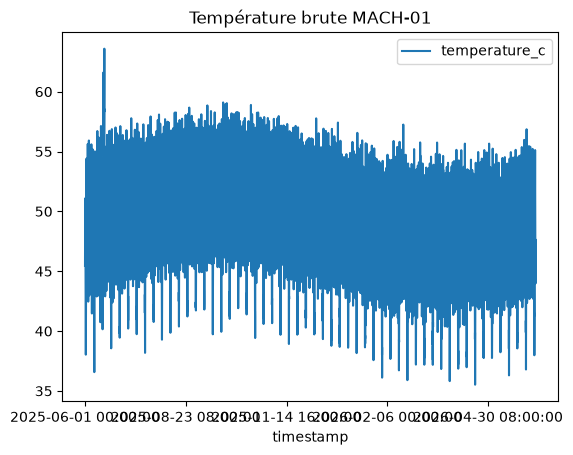

In [11]:
import matplotlib.pyplot as plt
bronze = datas

# Série temporelle brute d'une machine
m1 = bronze[bronze["machine_id"] == "MACH-01"]
m1.plot(x="timestamp", y="temperature_c", title="Température brute MACH-01")

run_dir = create_ingestion_dir(base="artifacts/ingestions", topic="incidents")
plt.savefig(run_dir / "temperature_mach01.png", bbox_inches="tight")
plt.show()

## Analyse de la distribution du df bronze

Répertoire créé : artifacts\ingestions\incidents\202606171652


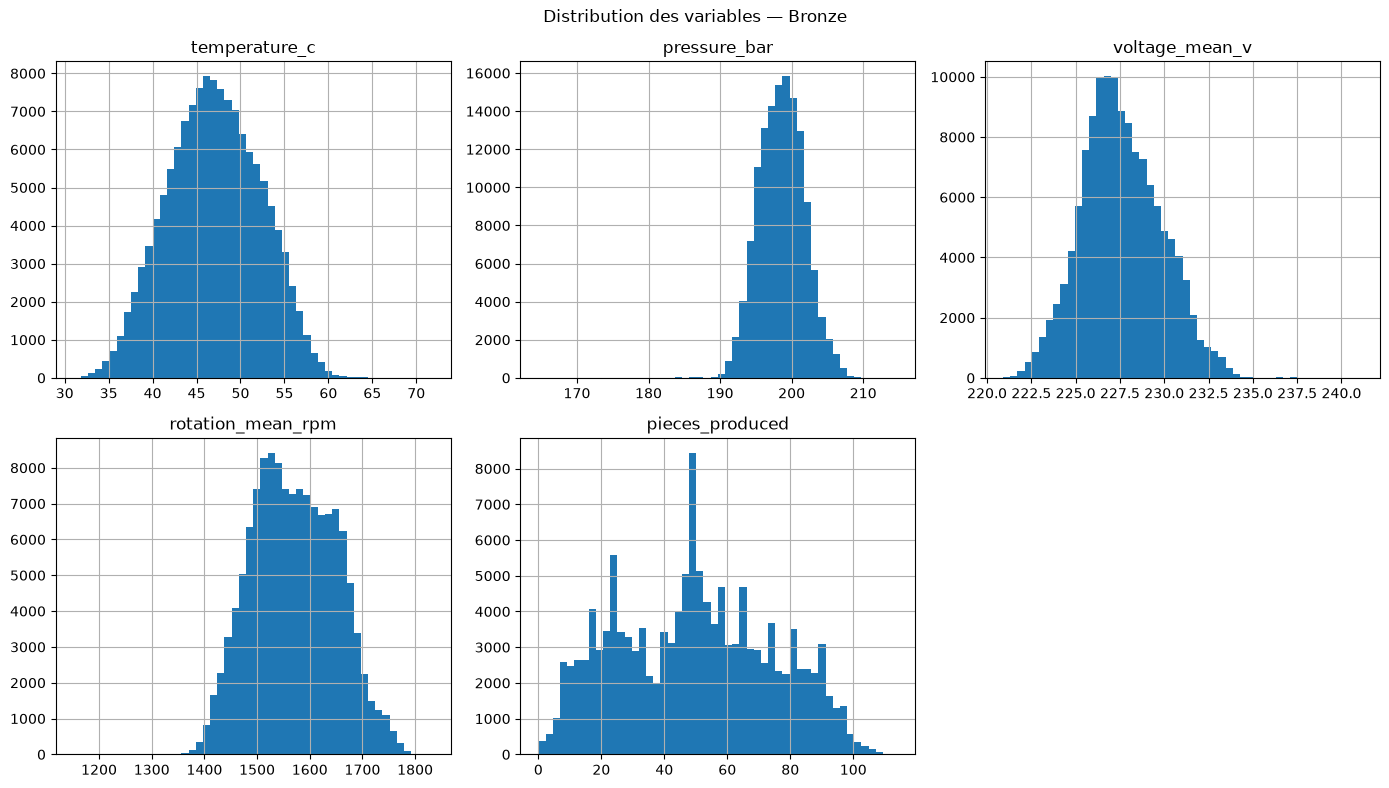

In [14]:
import matplotlib.pyplot as plt

numeric_cols = ["temperature_c", "pressure_bar", "voltage_mean_v", "rotation_mean_rpm", "pieces_produced"]

bronze[numeric_cols].hist(bins=50, figsize=(14, 8), layout=(2, 3))
plt.suptitle("Distribution des variables — Bronze")
plt.tight_layout()
run_dir = create_ingestion_dir(base="artifacts/ingestions", topic="incidents")
plt.savefig(run_dir / "Distribution des variables — Bronze.png", bbox_inches="tight")
plt.show()

## Boxplots par machine (pour détecter les outliers visuellement)

Répertoire créé : artifacts\ingestions\incidents\202606171654


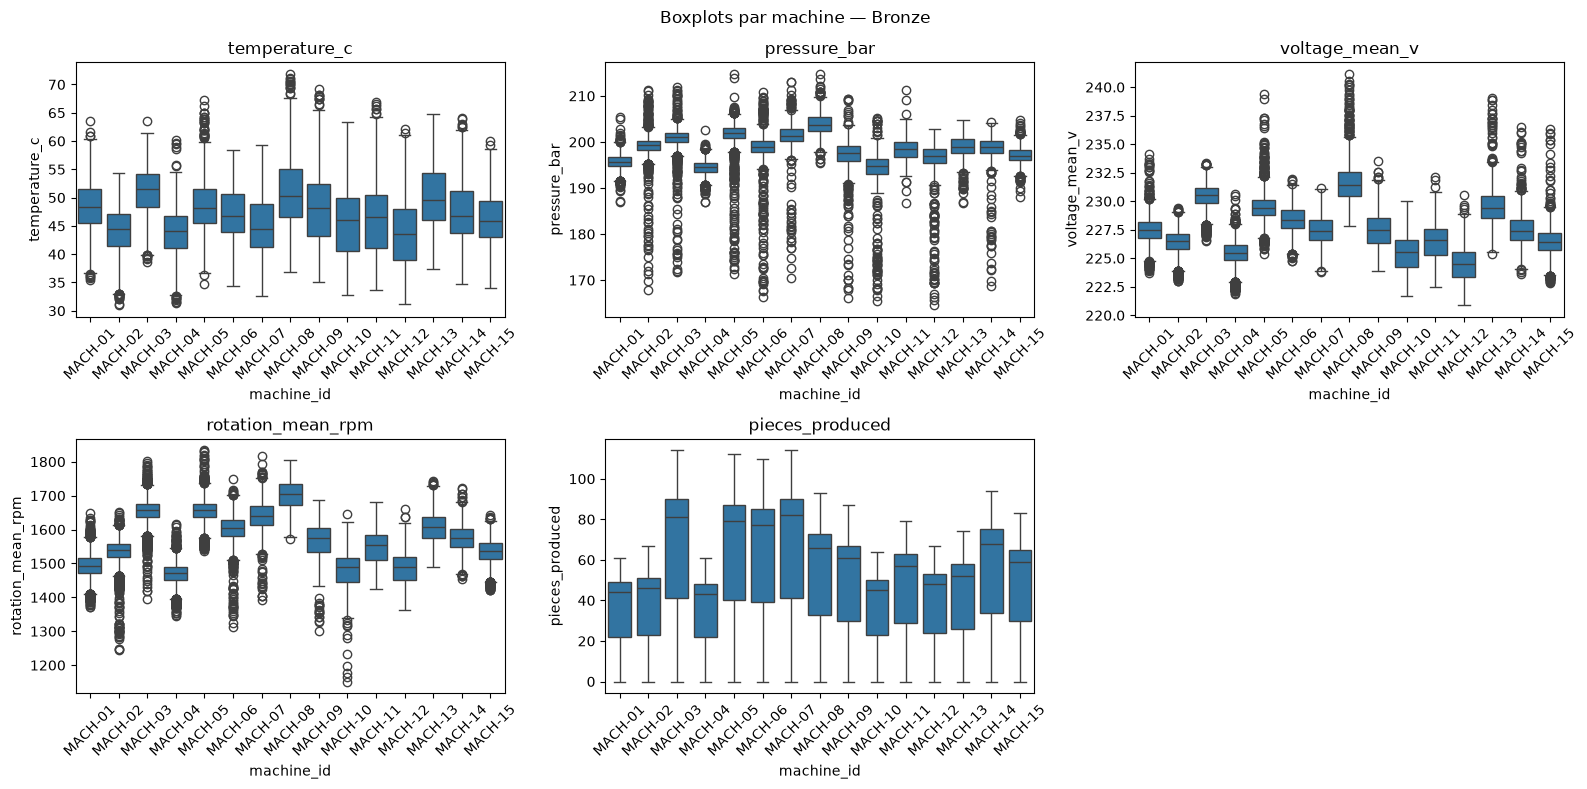

In [16]:
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=bronze, x="machine_id", y=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=45)

axes[-1].set_visible(False)
plt.suptitle("Boxplots par machine — Bronze")
plt.tight_layout()

run_dir = create_ingestion_dir(base="artifacts/ingestions", topic="incidents")
plt.savefig(run_dir / "Boxplots par machine — Bronze.png", bbox_inches="tight")
plt.show()

## Détecter visuellement les outliers (IQR)

In [17]:
for col in numeric_cols:
    Q1  = bronze[col].quantile(0.25)
    Q3  = bronze[col].quantile(0.75)
    IQR = Q3 - Q1
    low  = Q1 - 3 * IQR
    high = Q3 + 3 * IQR
    n = ((bronze[col] < low) | (bronze[col] > high)).sum()
    print(f"{col:25s} → {n} outliers  (bornes : [{low:.1f}, {high:.1f}])")

temperature_c             → 0 outliers  (bornes : [20.6, 73.6])
pressure_bar              → 219 outliers  (bornes : [182.7, 214.4])
voltage_mean_v            → 22 outliers  (bornes : [216.8, 238.4])
rotation_mean_rpm         → 0 outliers  (bornes : [1142.6, 1999.4])
pieces_produced           → 0 outliers  (bornes : [-88.0, 185.0])


## Production du silver 

In [9]:
import numpy as np

# ── Paramètres ─────────────────────────────────────────────────────────────
INPUT_PATH  = "telemetry.csv"
OUTPUT_PATH = "telemetry_silver.csv"

NUMERIC_COLS = [
    "temperature_c",
    "pressure_bar",
    "voltage_mean_v",
    "rotation_mean_rpm",
]

IQR_FACTOR = 3  # seuil outlier : Q1 - 3*IQR  /  Q3 + 3*IQR

# ── 1. Chargement ──────────────────────────────────────────────────────────
df = pd.read_csv(INPUT_PATH)

# ── 2. Typage ──────────────────────────────────────────────────────────────
df["timestamp"]  = pd.to_datetime(df["timestamp"])
df["machine_id"] = df["machine_id"].astype("category")

# ── 3. Tri chronologique ───────────────────────────────────────────────────
df = df.sort_values(["machine_id", "timestamp"]).reset_index(drop=True)

# ── 4. Colonnes temporelles ────────────────────────────────────────────────
df["year"]        = df["timestamp"].dt.year
df["month"]       = df["timestamp"].dt.month
df["day"]         = df["timestamp"].dt.day
df["hour"]        = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek  # 0 = lundi
df["is_weekend"]  = df["day_of_week"].isin([5, 6])

# ── 5. Flag arrêt machine ──────────────────────────────────────────────────
df["is_stopped"] = df["pieces_produced"] == 0

# ── 6. Détection outliers → NaN → interpolation par machine ───────────────
outlier_report = {}

for col in NUMERIC_COLS:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    low  = Q1 - IQR_FACTOR * IQR
    high = Q3 + IQR_FACTOR * IQR

    mask = (df[col] < low) | (df[col] > high)
    outlier_report[col] = int(mask.sum())
    df.loc[mask, col] = np.nan

# Interpolation linéaire par machine (comble les NaN créés ci-dessus)
df[NUMERIC_COLS] = (
    df.groupby("machine_id", observed=True)[NUMERIC_COLS]
      .transform(lambda g: g.interpolate(method="linear", limit_direction="both"))
)

# ── 7. Arrondi ─────────────────────────────────────────────────────────────
df[NUMERIC_COLS] = df[NUMERIC_COLS].round(2)

# ── 8. Renommage ───────────────────────────────────────────────────────────
df = df.rename(columns={
    "temperature_c":    "temp_c",
    "voltage_mean_v":   "voltage_v",
    "rotation_mean_rpm":"rotation_rpm",
})

# ── 9. Ordre des colonnes ──────────────────────────────────────────────────
cols = [
    "machine_id", "timestamp",
    "year", "month", "day", "hour", "day_of_week", "is_weekend",
    "temp_c", "pressure_bar", "voltage_v", "rotation_rpm",
    "pieces_produced", "is_stopped",
]
df = df[cols]

# ── 10. Export ─────────────────────────────────────────────────────────────
#df.to_csv(OUTPUT_PATH, index=False)
run_dir = create_ingestion_dir(base="artifacts/ingestions", topic="incidents")
df.to_csv(run_dir / OUTPUT_PATH, index=False)

# ── Rapport ────────────────────────────────────────────────────────────────
print(f"Shape          : {df.shape}")
print(f"NaN restants   : {df.isna().sum().sum()}")
print(f"Machines       : {df['machine_id'].nunique()}")
print(f"Période        : {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"Arrêts détectés: {df['is_stopped'].sum()}")
print()
print("Outliers traités :")
for col, n in outlier_report.items():
    print(f"  {col}: {n}")
print()
print(f"Fichier exporté : {OUTPUT_PATH}")

Répertoire créé : artifacts\ingestions\incidents\202606171639
Shape          : (134280, 14)
NaN restants   : 0
Machines       : 15
Période        : 2025-06-01 00:00:00 → 2026-06-08 23:00:00
Arrêts détectés: 116

Outliers traités :
  temperature_c: 0
  pressure_bar: 219
  voltage_mean_v: 22
  rotation_mean_rpm: 0

Fichier exporté : telemetry_silver.csv
